# Financial Performance Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sb

In [2]:
df = pd.read_excel('../Datasets/Credir_Card_Bank.xlsx')
df

,Customer_ID,Age,Gender,Employment_Type,Occupation,Monthly_Income,Annual_Income,Credit_Score,Years_With_Bank,Existing_Credit_Cards,...,Credit_Utilization,Credit_History_Years,Missed_Payments,Late_Payment_Count,Number_of_Defaults,Residential_Status,PAN_Verified,KYC_Status,Fraud_Flag,Credit_Limit
0,CUST00001,41,Female,Salaried,Sales Executive,140273,1683276,811,4,4,...,34,11,0,8,0,Rent,Yes,Complete,No,1373925
1,CUST00002,23,Male,Self-Employed,Business Owner,209521,2514252,837,12,2,...,71,20,3,3,0,Own,Yes,Complete,No,1902449
2,CUST00003,45,Female,Salaried,Designer,47682,572184,679,2,6,...,88,12,5,2,0,Rent,Yes,Complete,No,1165913
3,CUST00004,39,Male,Salaried,Doctor,214966,2579592,660,5,0,...,66,4,3,5,0,Rent,Yes,Complete,No,1869491
4,CUST00005,58,Male,Self-Employed,Designer,30051,360612,589,18,0,...,70,1,4,2,0,Own,Yes,Complete,No,825275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CUST04996,48,Male,Salaried,Doctor,55078,660936,824,12,1,...,91,7,4,4,0,Rent,Yes,Complete,No,1156917
4996,CUST04997,59,Female,Self-Employed,Accountant,107040,1284480,840,0,1,...,28,22,1,6,0,Own,Yes,Complete,No,1458578
4997,CUST04998,26,Female,Salaried,Doctor,168754,2025048,632,19,0,...,38,11,3,1,0,Rent,Yes,Complete,No,1342610
4998,CUST04999,42,Male,Salaried,Manager,197110,2365320,734,9,2,...,15,3,2,2,0,Own,Yes,Complete,No,1868828


#  Income vs Savings Analysis

In [3]:
df["Savings_Percentage"] = (
    df["Savings_Balance"] /
    df["Monthly_Income"]) * 100

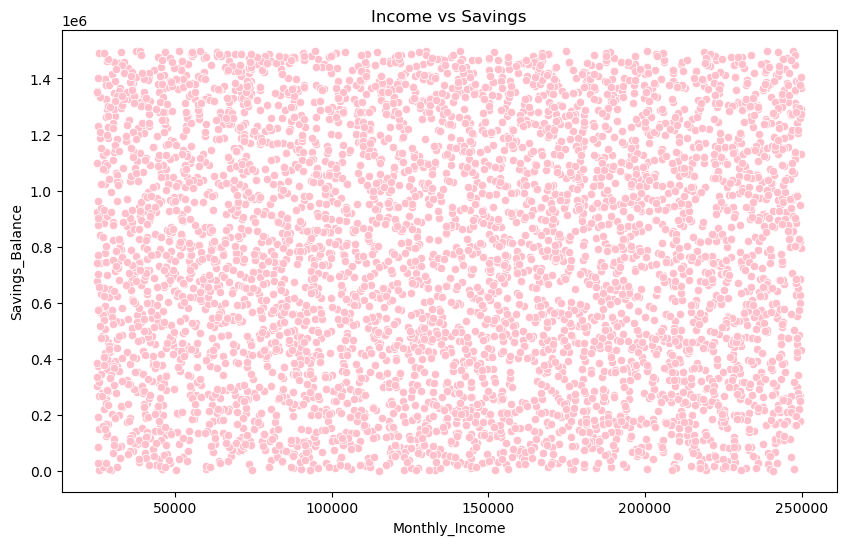

In [4]:
plt.figure(figsize=(10,6))

sb.scatterplot(
    x="Monthly_Income",
    y="Savings_Balance",
    data=df,
    color="pink"
)

plt.title("Income vs Savings")

plt.show()

In [5]:
df.groupby("Employment_Type")[["Annual_Income","Savings_Balance"]].describe().round(2)

Annual_Income                                             \
                        count        mean        std       min       25%   
Employment_Type                                                            
Salaried               2484.0  1656723.10  787563.54  300264.0  983364.0   
Self-Employed          2516.0  1634834.66  780139.19  300000.0  950697.0   

                                                 Savings_Balance             \
                       50%        75%        max           count       mean   
Employment_Type                                                               
Salaried         1663908.0  2338065.0  2996952.0          2484.0  765976.80   
Self-Employed    1639302.0  2286420.0  2998896.0          2516.0  743835.44   

                                                                              
                       std    min       25%       50%         75%        max  
Employment_Type                                                               
Salaried         435623.47  970.0  392445.0  764532.5  1148758.00  1499342.0  
Self-Employed    435457.67  565.0  369823.0  739742.0  1119575.25  1499571.0

Business Insight:

Customers with higher annual income generally save more money, making them ideal candidates for premium savings and investment products.

# Income vs Investments

In [6]:
df["Investment_Percentage"] = (
    df["Investment_Value"] /
    df["Monthly_Income"]) * 100

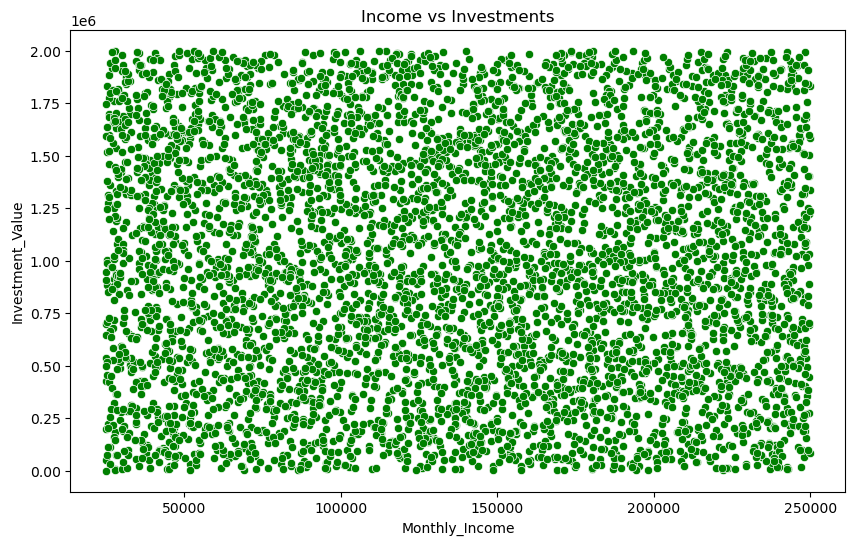

In [7]:
plt.figure(figsize=(10,6))

sb.scatterplot(
    x="Monthly_Income",
    y="Investment_Value",
    data=df,
    color="green")

plt.title("Income vs Investments")

plt.show()

In [8]:
df.groupby("Occupation")[["Annual_Income","Investment_Value"]].mean().round(2).sort_values(by="Annual_Income", ascending=False) .head(10)

,Annual_Income,Investment_Value
Occupation,,
Sales Executive,1686145.17,1016644.11
Teacher,1675778.15,974551.89
Manager,1656613.92,993248.76
Accountant,1654749.50,996195.75
Doctor,1643448.43,990876.67
Business Owner,1634368.95,967578.14
Software Engineer,1632766.46,1012937.42
Designer,1583056.92,989048.41


# EMI Analysis

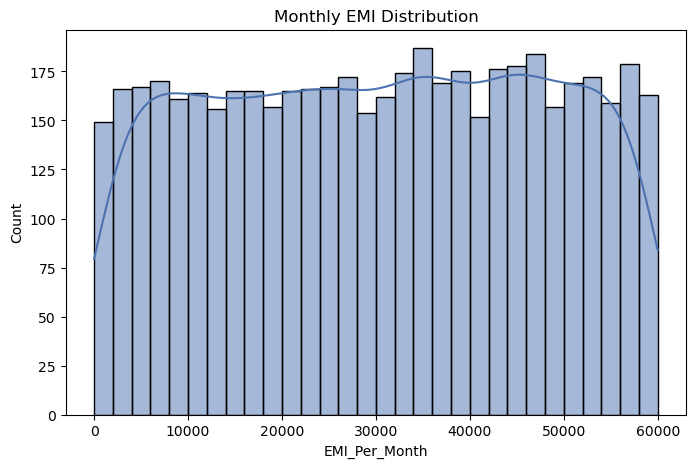

In [9]:
plt.figure(figsize=(8,5))
sb.histplot(df["EMI_Per_Month"],bins=30,kde=True, color="#4C72B0")
plt.title("Monthly EMI Distribution")
plt.show()

In [10]:
df[["EMI_Per_Month"]].describe().T

,count,mean,std,min,25%,50%,75%,max
EMI_Per_Month,5000.0,30315.4332,17256.150634,0.0,15384.5,30607.5,45254.5,60000.0


# Debt-to-Income Analysis

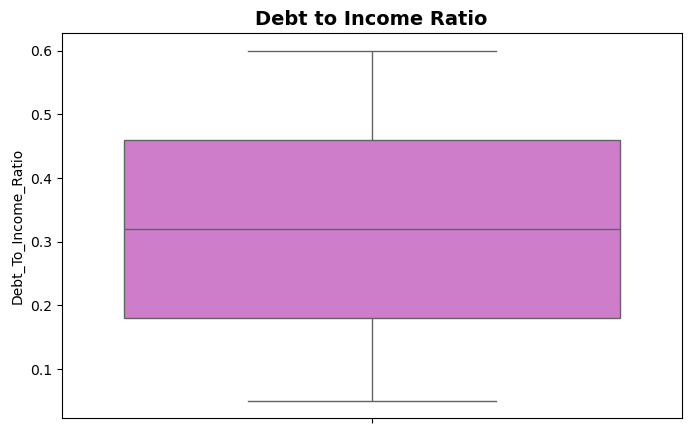

In [11]:
plt.figure(figsize=(8,5))

sb.boxplot(y=df["Debt_To_Income_Ratio"], color="orchid")

plt.title("Debt to Income Ratio", fontsize=14, fontweight="bold")

plt.show()

In [12]:
df.groupby("Employment_Type")["Debt_To_Income_Ratio"].mean()

Employment_Type
Salaried         0.323442
Self-Employed    0.323462
Name: Debt_To_Income_Ratio, dtype: float64

Business Insight: 

Customers with a higher debt-to-income ratio have lower repayment capacity, making them more likely to face loan repayment difficulties.

# Credit Utilization Analysis

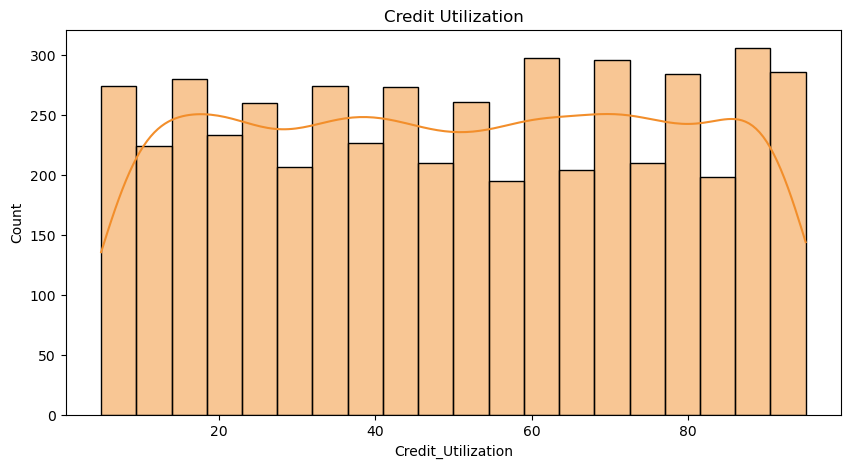

In [13]:
plt.figure(figsize=(10,5))

sb.histplot(df["Credit_Utilization"], bins=20, kde=True, color="#F28E2B")

plt.title("Credit Utilization")

plt.show()

In [14]:
df.groupby("Occupation")["Credit_Utilization"].mean()

Occupation
Accountant           49.964174
Business Owner       50.707317
Designer             49.594470
Doctor               48.377634
Manager              50.963272
Sales Executive      50.900602
Software Engineer    50.709924
Teacher              50.739130
Name: Credit_Utilization, dtype: float64

# Existing Credit Limit Analysis

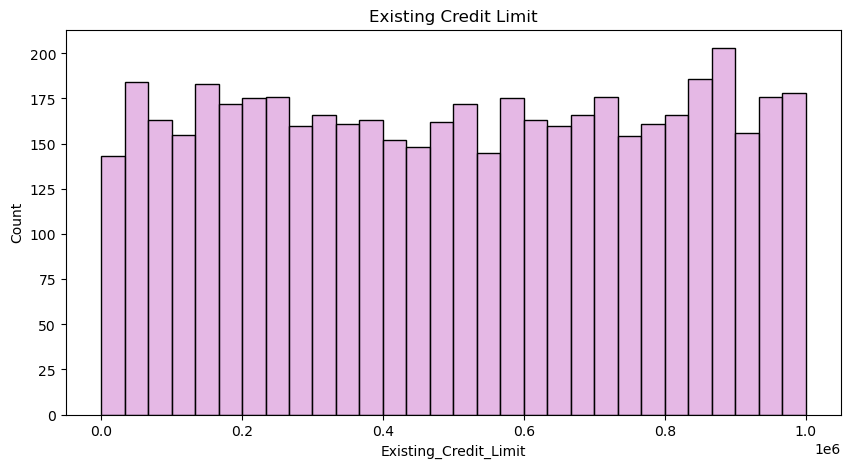

In [15]:
plt.figure(figsize=(10,5))

sb.histplot(df["Existing_Credit_Limit"],bins=30,color="plum")

plt.title("Existing Credit Limit")

plt.show()

In [16]:
df[["Existing_Credit_Limit"]].describe()

,Existing_Credit_Limit
count,5000.00000
mean,504801.14360
std,291438.83248
min,56.00000
25%,248594.50000
50%,506282.00000
75%,759980.25000
max,999955.00000


# Loan Portfolio Analysis

C:\Users\Saksh\AppData\Local\Temp\ipykernel_23464\1503587688.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(


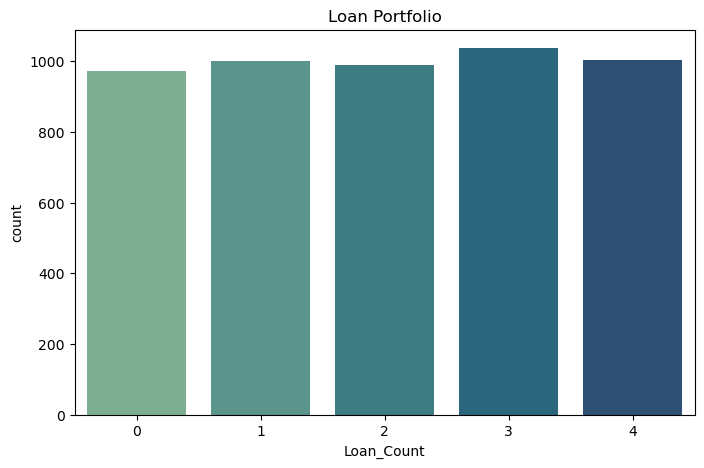

In [17]:
plt.figure(figsize=(8,5))

sb.countplot(
    data=df,
    palette="crest",
    x="Loan_Count")

plt.title("Loan Portfolio")

plt.show()

In [18]:
df.groupby("Loan_Count")[["Annual_Income","Credit_Score"]].mean().round(2)

,Annual_Income,Credit_Score
Loan_Count,,
0,1667118.68,704.07
1,1647493.56,700.30
2,1643254.14,697.30
3,1679282.79,706.81
4,1590867.70,700.96


# Banking KPI Report

In [19]:
kpi = {
"Total Customers":
df["Customer_ID"].nunique(),

"Average Monthly Income":
df["Monthly_Income"].mean(),

"Total Savings":
df["Savings_Balance"].sum(),

"Average Savings":
df["Savings_Balance"].mean(),

"Total Investments":
df["Investment_Value"].sum(),

"Average EMI":
df["EMI_Per_Month"].mean(),

"Average Debt To Income":
df["Debt_To_Income_Ratio"].mean(),

"Average Credit Utilization":
df["Credit_Utilization"].mean(),

"Average Credit Score":
df["Credit_Score"].mean(),

"Average Existing Credit Limit":
df["Existing_Credit_Limit"].mean()

}

pd.DataFrame(kpi.items(),
columns=["KPI","Value"]).round(2)

,KPI,Value
0,Total Customers,5.000000e+03
1,Average Monthly Income,1.371424e+05
2,Total Savings,3.774176e+09
3,Average Savings,7.548353e+05
4,Total Investments,4.966453e+09
5,Average EMI,3.031543e+04
6,Average Debt To Income,3.200000e-01
7,Average Credit Utilization,5.024000e+01
8,Average Credit Score,7.019200e+02
9,Average Existing Credit Limit,5.048011e+05


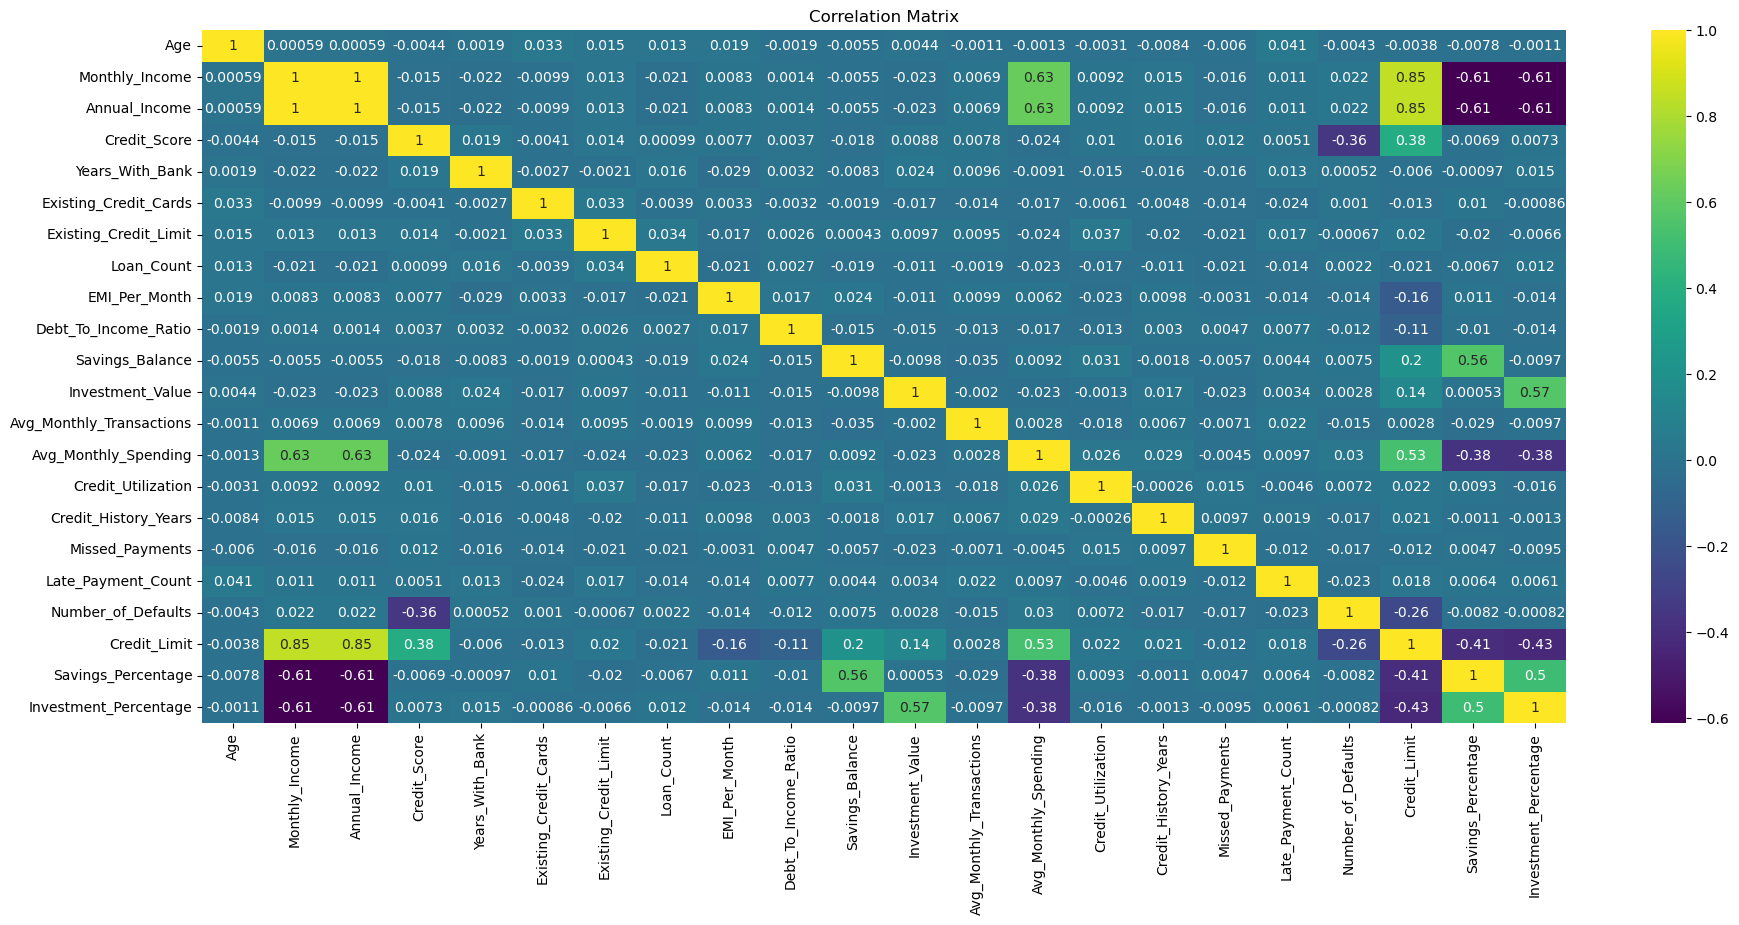

In [20]:
plt.figure(figsize=(22,9))

sb.heatmap(df.select_dtypes(include="number").corr(),annot=True,

cmap="viridis")

plt.title("Correlation Matrix")

plt.show()